In [2]:
import numpy as np
import matplotlib.pylab as plt
import uproot
import awkward as ak
import seaborn
import RA_funcs as rf
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import skew
import Scope_funcs as sf
import pyarrow as pa
import re

imports work
imports work


In [3]:
plt.rcParams.update({
    'figure.figsize': (8, 6), # figure size
    'font.size': 14,          # Default font size
    'figure.titlesize':14,   # suptitle size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 12,     # X and Y label font size
    'xtick.labelsize': 13,    # X-axis tick label size
    'ytick.labelsize': 13,    # Y-axis tick label size
    'legend.fontsize': 12     # Legend font size
})


<span style="font-family: arial; font-size:15px; color:pink">

## Functions

In [4]:
# plots the energy profile vs the x axis and fits to gaussian
def E_vs_X_scope_gaussian_fit(hit_data, chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4, return_param=False, Normalize=False, plane="false"):

    title = ("Shower Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")

    # filter data by chi2
    hit_data_chi2 = sf.filter_chi2_scope_data(hit_data,1/chi2, chi2)
    y_max, y_min

    # take the data from the seletced y range
    data = hit_data_chi2[ak.flatten((hit_data_chi2.tele.y < y_max) & (hit_data_chi2.tele.y > y_min))]
    data = data[ak.num(data.tele) == 1]


    # compute X and E
    X1 = -ak.to_numpy(ak.mean(data.tele.x, axis=1))
    X = bin_size * np.round(X1 / bin_size)
    
    if plane != "false":
        E_plane = data.hits[data.hits.plane == plane]
        E = ak.sum(E_plane.amp, axis=1)
        title = (f"Plane {plane + 1} Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")
    else:
        E = ak.sum(data.hits.amp, axis=1)


    # grouping
    amp, mean, pos = rf.ak_groupby(X, E, round="false")

    # statistics
    amp_avg = ak.mean(amp.data, axis=1)
    amp_std = ak.std(amp.data, axis=1) / np.sqrt(ak.num(amp.data, axis=1) - 1)

    # choose the range of X
    mask = (pos > x_min) & (pos < x_max)

    # convert Awkward → Numpy
    pos_m = ak.to_numpy(pos[mask])
    amp_m = ak.to_numpy(amp_avg[mask])
    err_m = ak.to_numpy(amp_std[mask])

    # Fitting

    #  Gaussian model 
    def gaussian_linear(x, c, A, mu, sigma):
        return c - A * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # initial guesses
    c0 = 6000
    A0 = np.min(amp_m)
    # mu0 = pos_m[np.argmin(amp_m)]
    mu0 = 0
    sigma0 = 3
    # sigma0 = (np.max(pos_m) - np.min(pos_m)) / 6


    # fit
    popt, pcov = curve_fit(gaussian_linear, pos_m, amp_m, p0=[c0, A0, mu0, sigma0], sigma=err_m, absolute_sigma=True)

    # fitted values
    c_fit, A_fit, mu_fit, sigma_fit = popt
    
    # uncertainties
    perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties
    c_err,  A_err, mu_err, sigma_err = perr

    # return the fitting results if needed
    if return_param:
        return popt, perr


    # chi2
    residuals = amp_m - gaussian_linear(pos_m, *popt)

    # avoid division by zero if any std are 0
    mask_err = err_m > 0
    chi2_val = np.sum((residuals[mask_err] / err_m[mask_err])**2)

    # number of points used in chi2
    N = np.sum(mask_err)
    
    # number of fit params (c, m, A, mu, sigma) = 5
    p = len(popt)
    ndof = N - p
    chi2_ndof = chi2_val / ndof if ndof > 0 else np.nan

    # plot
    fig, ax = plt.subplots()
    ax.errorbar(pos_m, amp_m, yerr=err_m, fmt='.', capsize=4, label="data")

    # make a smooth fitted function
    x_fit = np.linspace(np.min(pos_m), np.max(pos_m), 500)
    y_fit = gaussian_linear(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', label="Gaussian fit", zorder=10)

    # build textbox string
    textstr = "\n".join([
        r"$\chi^2/\mathrm{ndof} = %.2f$" % chi2_ndof,
        r"$c = %.3f \pm %.3f$" % (c_fit, c_err),
        r"$A = %.3f \pm %.3f$" % (A_fit, A_err),
        r"$\mu = %.3f \pm %.3f$" % (mu_fit, mu_err),
        r"$\sigma = %.3f \pm %.3f$" % (sigma_fit, sigma_err),
    ])

    # add textbox (axes coordinates: 0..1)
    ax.text(
        0.65, 0.36, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="pink", alpha=0.8, edgecolor="0.5")
    )

    ax.grid(True)
    ax.set_xlabel("X Telescope")
    ax.set_ylabel("Average Energy [MIP]")
    # ax.set_title(r"Average Energy vs Scope X Position \n Fit to $y = m \cdot x + c - A\cdot e^{\frac{-(x - \mu)^2}{(2 \sigma^2)}}$")
    ax.set_title(title)

    ax.legend(loc="upper left")
    # leg = ax.legend(loc="upper right", title=textstr, frameon=True)
    
    if Normalize:
        import matplotlib.ticker as ticker        
        # Define the division logic (e.g., divide by 1000)
        ax.set_yticks(np.linspace(0, c_fit, 11))
        formatter = ticker.FuncFormatter(lambda x, pos: f'{x/c_fit:.2f}')
        ax.yaxis.set_major_formatter(formatter)

    plt.show()



In [5]:
# get the gap parameters for each layer
def gap_per_layer(scope_data,chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4):

    # get the parameters per plane
    c_list = []
    c_err_list = []
    A_list = []
    A_err_list = []
    mu_list = []
    mu_err_list = []

    for plane in range(0,8):
        
        popt, perr = E_vs_X_scope_gaussian_fit(scope_data, chi2, y_min, y_max, x_min, x_max, bin_size, plane=plane, return_param=True)

        c_fit, c_err = popt[0], perr[0]
        A_fit, A_err = popt[1], perr[1]
        mu_fit, mu_err = popt[2], perr[2]

        c_list.append(c_fit)
        c_err_list.append(c_err)
        A_list.append(A_fit)
        A_err_list.append(A_err)
        mu_list.append(mu_fit)
        mu_err_list.append(mu_err)

    planes = 1 + np.arange(len(c_list))  # 0..7

    fig, axs = plt.subplots(3, 1, sharex=True)

    # c
    axs[0].errorbar(planes, c_list, yerr=c_err_list, fmt='o-', capsize=3)
    axs[0].set_ylabel("c")
    axs[0].grid(True, alpha=0.3)

    # A
    axs[1].errorbar(planes, A_list, yerr=A_err_list, fmt='o-', capsize=3, color="r")
    axs[1].set_ylabel("A")
    axs[1].grid(True, alpha=0.3)

    # A/C %
    axs[2].errorbar(planes, (np.array(A_list)/np.array(c_list))*100, yerr=np.array(A_err_list)+np.array(c_err_list), fmt='o-', capsize=3, color="r")
    axs[2].set_ylabel("Energy Loss [%]")
    axs[2].grid(True, alpha=0.3)
    axs[2].set_xlabel("Plane")


    fig.suptitle("Gap Gaussian Fit Parameters Per Plane")
    plt.tight_layout()
    plt.show()



In [6]:
# plots the energy profile vs the x axis and fits to gaussian
def E_vs_X_super_gaussian_fit(hit_data, chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4, return_param=False, Normalize=False, plane="false"):

    title = "Shower Average Energy vs Scope X Position \n \n Fit to Generalized Gaussian Distribution"


    # filter data by chi2
    hit_data_chi2 = sf.filter_chi2_scope_data(hit_data,1/chi2, chi2)
    y_max, y_min

    # take the data from the seletced y range
    data = hit_data_chi2[ak.flatten((hit_data_chi2.tele.y < y_max) & (hit_data_chi2.tele.y > y_min))]
    data = data[ak.num(data.tele) == 1]


    # compute X and E
    X1 = -ak.to_numpy(ak.mean(data.tele.x, axis=1))
    X = bin_size * np.round(X1 / bin_size)
    
    if plane != "false":
        E_plane = data.hits[data.hits.plane == plane]
        E = ak.sum(E_plane.amp, axis=1)
        title = (f"Plane {plane + 1} Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")
    else:
        E = ak.sum(data.hits.amp, axis=1)


    # grouping
    amp, mean, pos = rf.ak_groupby(X, E, round="false")

    # statistics
    amp_avg = ak.mean(amp.data, axis=1)
    amp_std = ak.std(amp.data, axis=1) / np.sqrt(ak.num(amp.data, axis=1) - 1)

    # choose the range of X
    mask = (pos > x_min) & (pos < x_max)

    # convert Awkward → Numpy
    pos_m = ak.to_numpy(pos[mask])
    amp_m = ak.to_numpy(amp_avg[mask])
    err_m = ak.to_numpy(amp_std[mask])

    # Fitting

    #  Gaussian model 
    def super_gaussian(x, c, A, mu, sigma, beta):
        return c - A * np.exp(-(np.abs((x - mu))/sigma)**beta)

    # initial guesses
    c0 = 50
    A0 = np.min(amp_m)
    # mu0 = pos_m[np.argmin(amp_m)]
    mu0 = 0
    sigma0 = 3
    beta0 = 2
    # sigma0 = (np.max(pos_m) - np.min(pos_m)) / 6


    # fit
    popt, pcov = curve_fit(super_gaussian, pos_m, amp_m, p0=[c0, A0, mu0, sigma0, beta0], sigma=err_m, absolute_sigma=True)

    # fitted values
    c_fit, A_fit, mu_fit, sigma_fit, beta_fit = popt
    
    # uncertainties
    perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties
    c_err,  A_err, mu_err, sigma_err, beta_err = perr

    # return the fitting results if needed
    if return_param:
        return popt, perr


    # chi2
    residuals = amp_m - super_gaussian(pos_m, *popt)

    # avoid division by zero if any std are 0
    mask_err = err_m > 0
    chi2_val = np.sum((residuals[mask_err] / err_m[mask_err])**2)

    # number of points used in chi2
    N = np.sum(mask_err)
    
    # number of fit params (c, m, A, mu, sigma) = 5
    p = len(popt)
    ndof = N - p
    chi2_ndof = chi2_val / ndof if ndof > 0 else np.nan

    # plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(pos_m, amp_m, yerr=err_m, fmt='.', capsize=4, label="data")

    # make a smooth fitted function
    x_fit = np.linspace(np.min(pos_m), np.max(pos_m), 500)
    y_fit = super_gaussian(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', label="Generalized Gaussian fit", zorder=10)

    # build textbox string
    textstr = "\n".join([
        r"$\chi^2/\mathrm{ndof} = %.2f$" % chi2_ndof,
        r"$c = %.3f \pm %.3f$" % (c_fit, c_err),
        r"$A = %.3f \pm %.3f$" % (A_fit, A_err),
        r"$\mu = %.3f \pm %.3f$" % (mu_fit, mu_err),
        r"$\sigma = %.3f \pm %.3f$" % (sigma_fit, sigma_err),
        r"$\beta = %.3f \pm %.3f$" % (beta_fit, beta_err)
    ])

    # add textbox (axes coordinates: 0..1)
    ax.text(
        0.65, 0.36, textstr,
        transform=ax.transAxes,
        # fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="pink", alpha=0.8, edgecolor="0.5")
    )

    ax.grid(True)
    ax.set_xlabel("X Telescop [mm]")
    ax.set_ylabel("Average Energy [MIP]")
    # ax.set_title(r"Average Energy vs Scope X Position \n Fit to $y = m \cdot x + c - A\cdot e^{\frac{-(x - \mu)^2}{(2 \sigma^2)}}$")
    ax.set_title(title)

    ax.legend(loc="center right")
    # leg = ax.legend(loc="upper right", title=textstr, frameon=True)
    
    if Normalize:
        import matplotlib.ticker as ticker        
        # Define the division logic (e.g., divide by 1000)
        ax.set_yticks(np.linspace(0, c_fit, 11))
        formatter = ticker.FuncFormatter(lambda x, pos: f'{x/c_fit:.2f}')
        ax.yaxis.set_major_formatter(formatter)
        ax.set_ylabel("Energy [%]")


    plt.show()



In [7]:
# get the gap parameters for each layer supergaussian
def gap_per_layer_supergaussian(scope_data,chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4):

    # get the parameters per plane
    c_list = []
    c_err_list = []
    A_list = []
    A_err_list = []
    mu_list = []
    mu_err_list = []
    beta_list = []
    beta_err_list = []

    for plane in range(0,8):
        
        popt, perr = E_vs_X_super_gaussian_fit(scope_data, chi2, y_min, y_max, x_min, x_max, bin_size, plane=plane, return_param=True)

        c_fit, c_err = popt[0], perr[0]
        A_fit, A_err = popt[1], perr[1]
        mu_fit, mu_err = popt[2], perr[2]
        beta_fit, beta_err = popt[4], perr[4]

        c_list.append(c_fit)
        c_err_list.append(c_err)
        A_list.append(A_fit)
        A_err_list.append(A_err)
        mu_list.append(mu_fit)
        mu_err_list.append(mu_err)
        beta_list.append(beta_fit)
        beta_err_list.append(beta_err)

    planes = 1 + np.arange(len(c_list))  # 0,1,...,7

    fig, axs = plt.subplots(4, 1, figsize=(6,8), sharex=True)

    # c
    axs[0].errorbar(planes, c_list, yerr=c_err_list, fmt='o-', capsize=3)
    axs[0].set_ylabel("c")
    axs[0].grid(True, alpha=0.3)

    # A
    axs[1].errorbar(planes, A_list, yerr=A_err_list, fmt='o-', capsize=3, color="r")
    axs[1].set_ylabel("A")
    axs[1].grid(True, alpha=0.3)
    # axs[1].set_xlabel("Plane")

    # A/C %
    axs[2].errorbar(planes, (np.array(A_list)/np.array(c_list))*100, yerr=np.array(A_err_list)+np.array(c_err_list), fmt='o-', capsize=3, color="r")
    axs[2].set_ylabel("Energy Loss [%]")
    axs[2].grid(True, alpha=0.3)
    # axs[2].set_xlabel("Plane")

    # Beta
    axs[3].errorbar(planes, beta_list, yerr=beta_err_list, fmt='o-', capsize=3, color="r")
    axs[3].set_ylabel("Beta")
    axs[3].grid(True, alpha=0.3)
    axs[3].set_xlabel("Plane")

    fig.suptitle("Gap Super Gaussian Fit Parameters Per Plane")
    plt.tight_layout()
    plt.show()



In [8]:
# plots the gap parameters for different sections of y on the shower
def plot_gap_per_y_supergaussian(data, y_range=10, y_bins=1, chi2=1):

    # lists for the plotting
    c_list = []
    c_err_list = []
    A_list = []
    A_err_list = []
    mu_list = []
    mu_err_list = []
    sigma_list = []
    sigma_err_list = []
    y_list = []

    x_center, y_center = sf.avg_energy_scope_colormap(data, x_shift=-3, y_borders=23 , amp_thresh=800)
    x_min, x_max = x_center-12, x_center+12



    for i in np.arange(y_center-y_range, y_center+y_range, y_bins):

        # get the gaussian parameters for each y
        popt, perr = E_vs_X_super_gaussian_fit(data, chi2, i, i+y_bins, x_min, x_max, bin_size=0.2, return_param=True)
        # E_vs_X_super_gaussian_fit(scope_data, chi2, i, i+y_bins, x_min, x_max, bin_size=0.2)
        c, A, mu, sigma, beta = popt
        c_err, A_err, mu_err, sigma_err, beta_err = perr
        
        y = i + y_bins/2
        y_list.append(y)

        # save the data
        c_list.append(c)
        c_err_list.append(c_err)
        A_list.append(A)
        A_err_list.append(A_err)
        mu_list.append(mu)
        mu_err_list.append(mu_err)
        sigma_list.append(sigma)
        sigma_err_list.append(sigma_err)


    # plot the parameters
    fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    linewdith = 1
    markersize = 3

    # plot C
    axs[0,0].errorbar(y_list, c_list, yerr=c_err_list, fmt='.', capsize=4, label="data")
    axs[0, 0].set_title("Average Signal Outside the Gap (c)")
    axs[0,0].set_ylabel("Energy Count [MIP]")

    # plot A
    axs[0,1].errorbar(y_list, A_list, yerr=A_err_list, fmt='.', color="red", capsize=4, label="data")
    axs[0, 1].set_title("Maximal Signal Loss (Gaussian Depth - A)")
    axs[0,1].set_ylabel("Energy Count Inside the Gap [MIP]")

    # plot gaussian mean (mu)
    axs[1,0].errorbar(y_list, mu_list, yerr=mu_err_list, fmt='.', color="purple", capsize=4, label="data")
    axs[1, 0].set_title("Gap Position on the scope (mu)")
    axs[1,0].set_ylabel("Gap Position [mm]")

    # plot gaussian width (sigma)
    axs[1,1].errorbar(y_list, sigma_list, yerr=sigma_err_list, fmt='.', color="green", capsize=4, label="data")
    axs[1, 1].set_title("Gap width (sigma)")
    axs[1,1].set_ylabel("sigma [mm]")

    for ax in axs.ravel():
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("y")
        ax.tick_params(axis="x", labelleft=True)

    plt.show()

In [9]:
def get_calibration_factors_with_plane_and_A_averaging(path_to_calibration_file, channel_to_A, return_group_avg=False):
    """
    Returns a 2D NumPy array serving as a lookup table for calibration factors.

    For pads with failed calibration (MPV <= 0), replaces with the average MPV
    of all successful calibrations in the same plane AND with the same A-value.

    If all MPVs in a given (plane, A) group are failed/zero, they are left as 0.
    """

    cal_data = np.loadtxt(path_to_calibration_file)

    # Extract columns
    cal_ch = cal_data[:, 0].astype(int)
    cal_plane = cal_data[:, 1].astype(int)
    mpv = cal_data[:, 5].copy()

    # Get A-value for each channel
    A_values = np.array([channel_to_A.get(ch, -1) for ch in cal_ch])

    # Compute averages for each (plane, A) group, excluding failed MPVs
    unique_planes = np.unique(cal_plane)
    unique_A_values = np.unique(A_values)

    group_averages = {}

    for plane in unique_planes:
        for A in unique_A_values:
            group_mask = (cal_plane == plane) & (A_values == A)
            group_mpvs = mpv[group_mask]

            if len(group_mpvs) == 0:
                continue

            non_zero_mpvs = group_mpvs[group_mpvs > 0]

            n_total = len(group_mpvs)
            n_zero = np.sum(group_mpvs <= 0)

            if len(non_zero_mpvs) > 0:
                avg_mpv = np.mean(non_zero_mpvs)
                group_averages[(plane, A)] = avg_mpv

    if return_group_avg:
        return group_averages
    
    # Replace failed MPVs only if a valid group average exists
    n_replaced = 0
    n_left_zero = 0

    for i in range(len(mpv)):
        if mpv[i] <= 0:
            key = (cal_plane[i], A_values[i])
            if key in group_averages:
                mpv[i] = group_averages[key]
                n_replaced += 1
            else:
                # keep it at 0 if the whole (plane, A) group failed
                mpv[i] = 0
                n_left_zero += 1

    print(f"✅ Replaced {n_replaced} failed calibrations with plane+A averages")
    print(f"⚠️ Left {n_left_zero} failed calibrations at 0 because their whole group was failed")

    # Convert to calibration factors safely
    cal_facs = np.zeros_like(mpv)
    valid_mask = mpv > 0
    cal_facs[valid_mask] = 1.0 / mpv[valid_mask]

    # Create lookup table
    lookup_table = np.zeros((11, 256))
    lookup_table[cal_plane, cal_ch] = cal_facs

    return lookup_table



def load_channel_to_A_from_header(path_to_header):
    """
    Parse ChannelMap.h and return a dict: channel -> A-value
    Expects entries like:
        {2, {0, 17}}
    """
    with open(path_to_header, "r") as f:
        text = f.read()

    pattern = r'\{\s*(\d+)\s*,\s*\{\s*(\d+)\s*,\s*(\d+)\s*\}\s*\}'
    matches = re.findall(pattern, text)

    channel_to_A = {}
    for ch_str, A_str, _ in matches:
        ch = int(ch_str)
        A = int(A_str)
        channel_to_A[ch] = A

    return channel_to_A


def convert_amp_to_MIP_asic_avg(data, number_of_planes=8):
    """takes aligned or synchronized zipped data and calibrates the amp to MIP
    using the avg mpv in the asic as cal factor for unsucceful calibrations"""

    path_to_calibration_file = "CalibrationFactors.txt"

    # 1. take the arrays from zipped file
    hits = data.hits
    planes, channels, amp = hits.plane, hits.ch, hits.amp

    # 2. table with the calibration for each plane and pad
    channel_to_A = load_channel_to_A_from_header("ChannelMap.h")
    lookup_table = get_calibration_factors_with_plane_and_A_averaging(path_to_calibration_file,channel_to_A)
    
    # 3. Shift the plane IDs to match calibration logic
    # (e.g., if 8 planes config, shift hit planes to match cal_plane 3-10)
    cal_planes_to_use = planes + 11 - number_of_planes

    # 4. match the calibration factor for each amp
    # - flatten the jagged arrays to use as indices for the NumPy lookup table
    flat_planes = ak.flatten(cal_planes_to_use).to_numpy().astype(int)
    flat_channels = ak.flatten(channels).to_numpy().astype(int)
    
    # - Get the factors for each plane and channel in 1d list
    flat_factors = lookup_table[flat_planes, flat_channels]

    # 5. Apply factors and restore jagged structure
    # Use ak.unflatten convert the 1d factors to jagged array in the shape of amp
    hits_per_event = ak.num(amp)
    cal_factors_jagged = ak.unflatten(flat_factors, hits_per_event)
    cal_amp = amp * cal_factors_jagged

    # 6. zip the hits and scope with the calibrated amplitudes
    tele = data.tele
    cal_hits = ak.zip({"plane":planes, "ch":channels, "amp":cal_amp})


    cal_data = ak.zip({"hits":cal_hits, "tele":tele},depth_limit=1)

    return cal_data

In [10]:
# Signal distribution over x fitted to a constant for runs OFF the gap
def E_vs_X_constant_fit(hit_data, chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4, return_param=False, Normalize=False, plane="false"):

    title = "Shower Average Energy vs Scope X Position \n \n Fit to Constant"

    # ... [Keep your data filtering and grouping logic the same until the Fitting section] ...

    # filter data by chi2
    hit_data_chi2 = sf.filter_chi2_scope_data(hit_data,1/chi2, chi2)
    y_max, y_min

    # take the data from the seletced y range
    data = hit_data_chi2[ak.flatten((hit_data_chi2.tele.y < y_max) & (hit_data_chi2.tele.y > y_min))]
    data = data[ak.num(data.tele) == 1]


    # compute X and E
    X1 = -ak.to_numpy(ak.mean(data.tele.x, axis=1))
    X = bin_size * np.round(X1 / bin_size)
    
    if plane != "false":
        E_plane = data.hits[data.hits.plane == plane]
        E = ak.sum(E_plane.amp, axis=1)
        title = (f"Plane {plane + 1} Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")
    else:
        E = ak.sum(data.hits.amp, axis=1)


    # grouping
    amp, mean, pos = rf.ak_groupby(X, E, round="false")

    # statistics
    amp_avg = ak.mean(amp.data, axis=1)
    amp_std = ak.std(amp.data, axis=1) / np.sqrt(ak.num(amp.data, axis=1) - 1)

    # choose the range of X
    mask = (pos > x_min) & (pos < x_max)

    # convert Awkward → Numpy
    pos_m = ak.to_numpy(pos[mask])
    amp_m = ak.to_numpy(amp_avg[mask])
    err_m = ak.to_numpy(amp_std[mask])
    

    if len(amp_m) == 0:
        print("No data in range.")
        return

    # --- WEIGHTED MEAN CALCULATION ---
    # Weights are 1/sigma^2
    weights = 1.0 / (err_m**2)
    
    # Weighted Mean (the constant 'c')
    c_fit = np.sum(weights * amp_m) / np.sum(weights)
    
    # Error on the Weighted Mean
    c_err = np.sqrt(1.0 / np.sum(weights))
    
    # For Chi2 calculation, we treat c_fit as popt
    popt = [c_fit] 
    # ---------------------------------

    # Chi2 calculation
    residuals = amp_m - c_fit
    chi2_val = np.sum((residuals / err_m)**2)
    ndof = len(amp_m) - 1
    chi2_ndof = chi2_val / ndof if ndof > 0 else np.nan

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(pos_m, amp_m, yerr=err_m, fmt='.', capsize=4, label="Data")
    
    # Horizontal line at the weighted mean
    ax.axhline(c_fit, color='r', linestyle='-', label=f"Weighted Mean: {c_fit:.2f}", zorder=10)

    # maximum deviation from the avg
    max_dev = np.max(np.abs(amp_m - c_fit))
    max_dev_pct = (max_dev / c_fit) * 100

    # Weighted Standard Deviation (Spread of the points)
    # This represents the "width" of the energy distribution across X
    variance_w = np.sum(weights * (amp_m - c_fit)**2) / np.sum(weights)
    std_w = np.sqrt(variance_w)
    std_pct = (std_w / c_fit) * 100

    textstr = "\n".join([
    r"$\chi^2/\mathrm{ndof} = %.2f$" % chi2_ndof,
    r"Avg Signal = $%.3f \pm %.3f$" % (c_fit, c_err),
    r"Std Dev = $%.3f$ (%.2f%%)" % (std_w, std_pct),
    r"Max Dev = $%.3f$ (%.2f%%)" % (max_dev, max_dev_pct)
    ])


    ax.text(
        0.65, 0.95, textstr, # Moved up for visibility
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="pink", alpha=0.8, edgecolor="0.5")
    )

    ax.grid(True)
    ax.set_xlabel("X Telescop [mm]")
    ax.set_ylabel("Average Energy [MIP]")
    ax.set_title(title)
    ax.legend(loc="best")
    
    # ... [Keep your Normalize logic the same] ...

    plt.show()


<span style="font-family: arial; font-size:15px; color:pink">

## Read Pad Corrected Data

✅ Replaced 263 failed calibrations with plane+A averages
⚠️ Left 192 failed calibrations at 0 because their whole group was failed


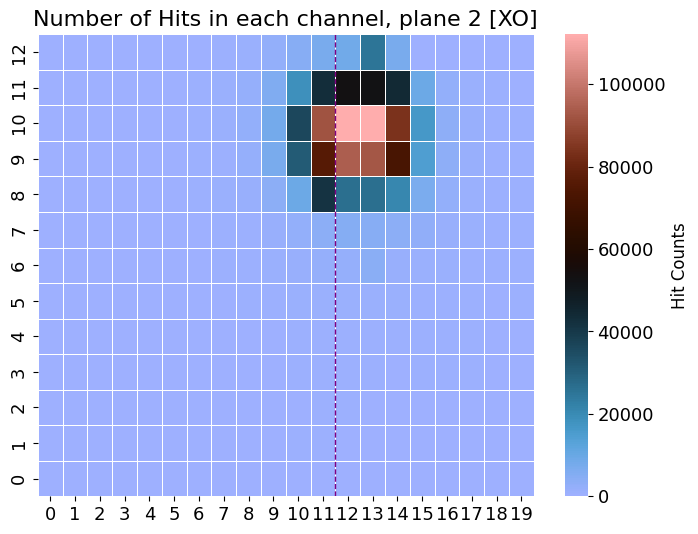

event number: 446133


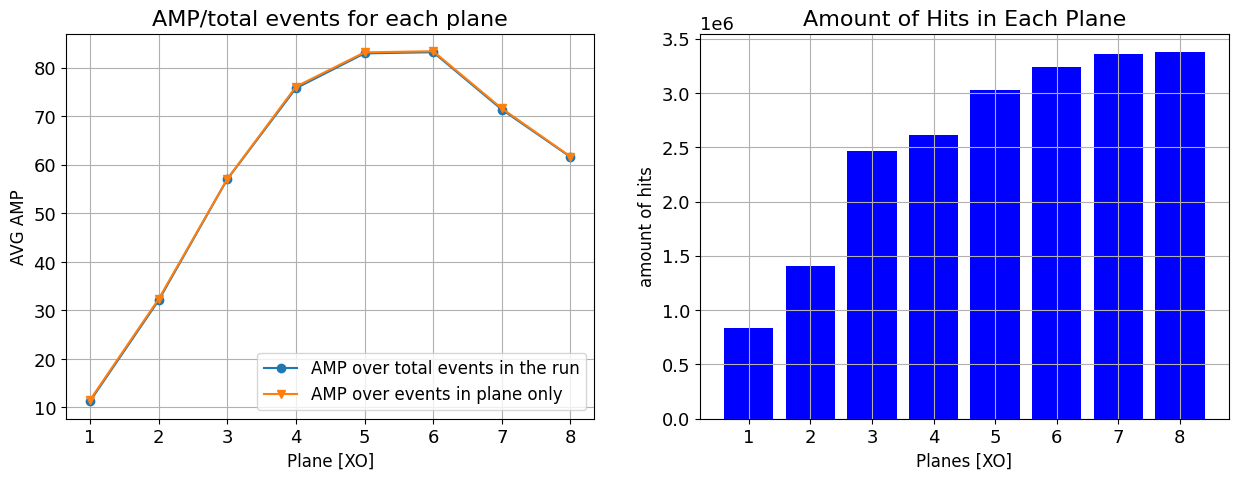

In [11]:
# run number
run_number = 1079

# IF NEEDED: create a file with pad reconstructed data using z average method
# rf.create_pad_corrected_data(1079, correction_radius=6, aligned=True)

# Read data
data_scope_corrected = ak.from_parquet(f"TB_FIRE/Pad_Corrected_Data/run_{run_number}_pad_corrected.parquet")
data_mip = convert_amp_to_MIP_asic_avg(data_scope_corrected, number_of_planes=8)
data_scope = data_mip

# Beam position in the run
rf.hits_amount_colormap_single_plane(data_scope.hits, 2)

# Shower development over z
rf.average_amp_vs_plane(data_scope.hits)


<span style="font-family: arial; font-size:15px; color:pink">

## Gap Analysis Full Shower

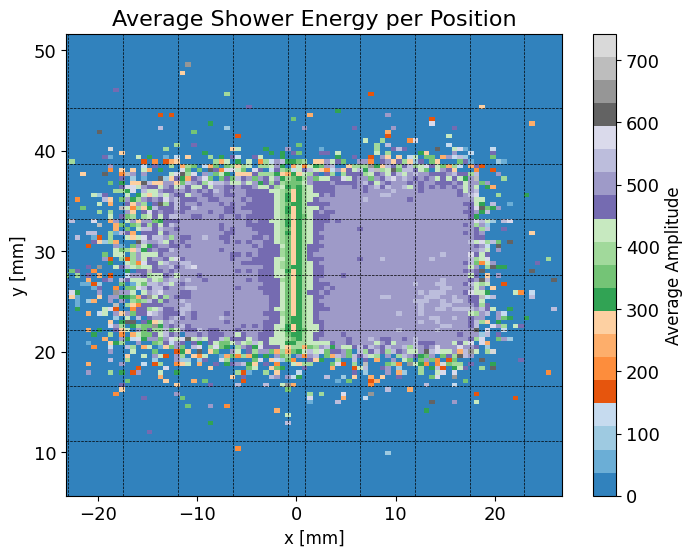

/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_76405/916365436.py:48: RuntimeWarning: invalid value encountered in power
  return c - A * np.exp(-(np.abs((x - mu))/sigma)**beta)


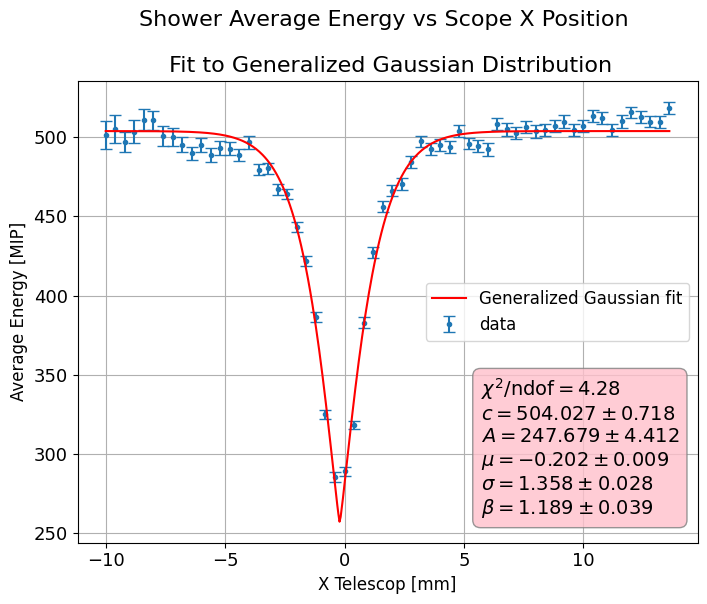

In [12]:
# Signal colormap for initial x,y from scope. and the x,y coordinates of the center of the beam
x_center, y_center = sf.avg_energy_scope_colormap(data_scope, x_shift=-3, y_borders=23 , amp_thresh=800)


# Define the parameters to project the signal from the colormap to the x axis
chi2 = 1.1
y_range = 20
x_range = 12
y_min, y_max = y_center - y_range, y_center + y_range
x_min, x_max = x_center - x_range, x_center + x_range

# Signal over x supergaussian fit
E_vs_X_super_gaussian_fit(data_scope, chi2, y_min, y_max, x_min, x_max, bin_size=0.4)


<span style="font-family: arial; font-size:15px; color:pink">

## Gap Analysis Per Layer

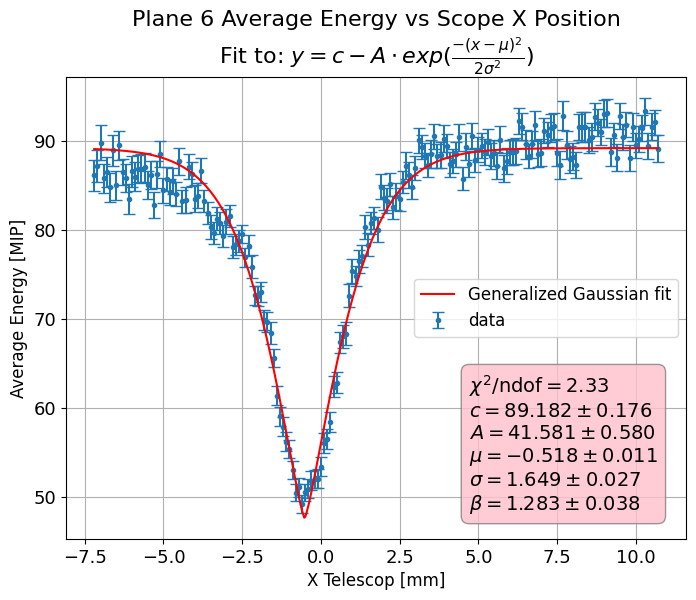

In [13]:
# Gap fit for signal in a specific planes
chi2 = 1.3
plane = 5
E_vs_X_super_gaussian_fit(data_scope, chi2, y_min, y_max, x_min+3, x_max-3, bin_size=0.1, plane=plane)

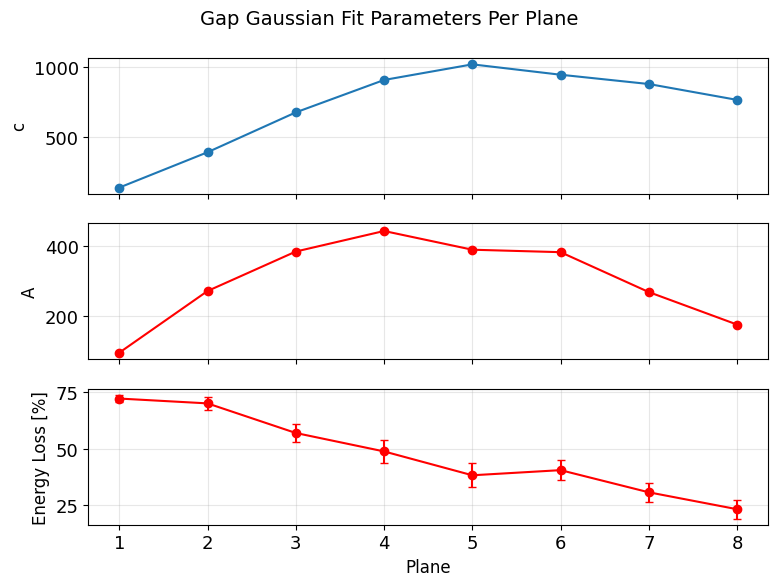

/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_76405/916365436.py:48: RuntimeWarning: invalid value encountered in power
  return c - A * np.exp(-(np.abs((x - mu))/sigma)**beta)


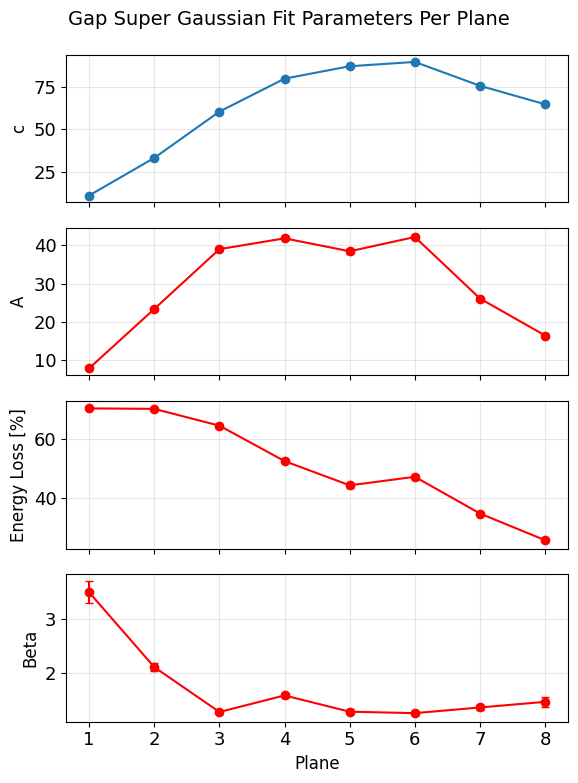

In [14]:
# Gap fit parameters in each plane
chi2 = 1.3
gap_per_layer(data_scope_corrected, chi2, y_min, y_max, x_min, x_max, bin_size=0.5)

gap_per_layer_supergaussian(data_scope, chi2, y_min, y_max, x_min, x_max, bin_size=0.06)

<span style="font-family: arial; font-size:15px; color:pink">

## Gap Parameters for different sections of y

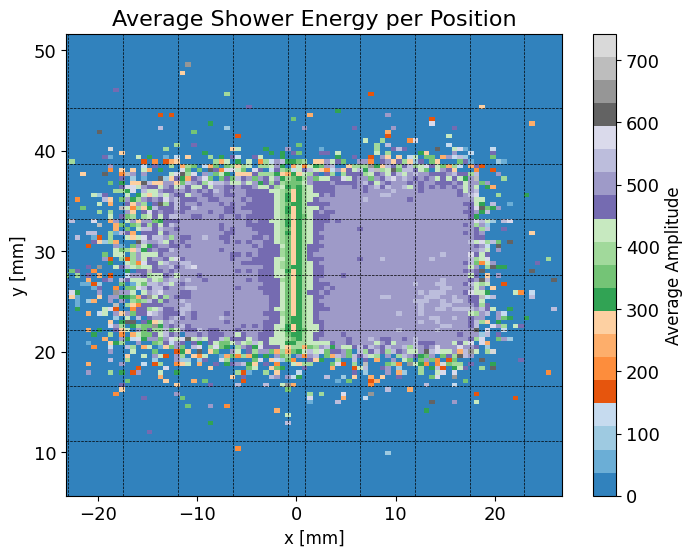

/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_76405/916365436.py:48: RuntimeWarning: invalid value encountered in power
  return c - A * np.exp(-(np.abs((x - mu))/sigma)**beta)


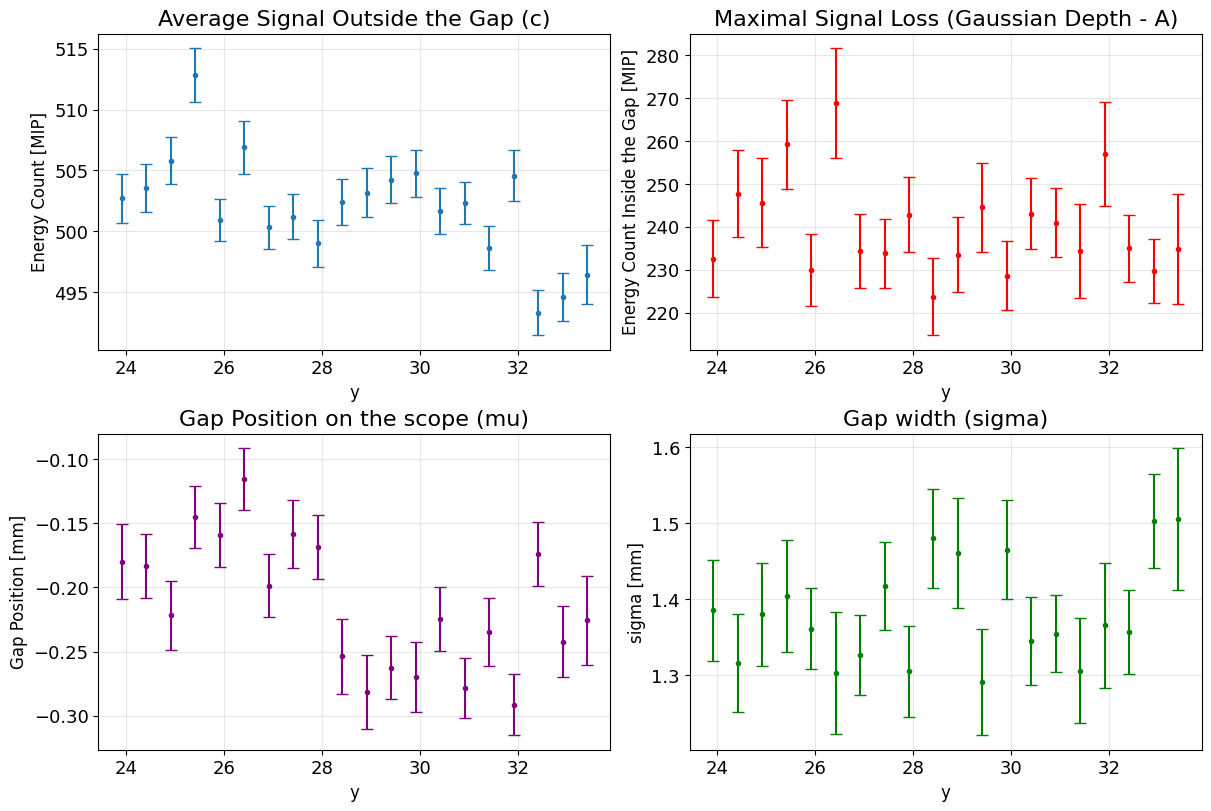

In [15]:
# Gets the gap parameters for varying sections of y
plot_gap_per_y_supergaussian(data_scope, y_range=5, y_bins=0.5, chi2=1.3)

<span style="font-family: arial; font-size:15px; color:pink">

## Signal distribution OFF gap

✅ Replaced 263 failed calibrations with plane+A averages
⚠️ Left 192 failed calibrations at 0 because their whole group was failed


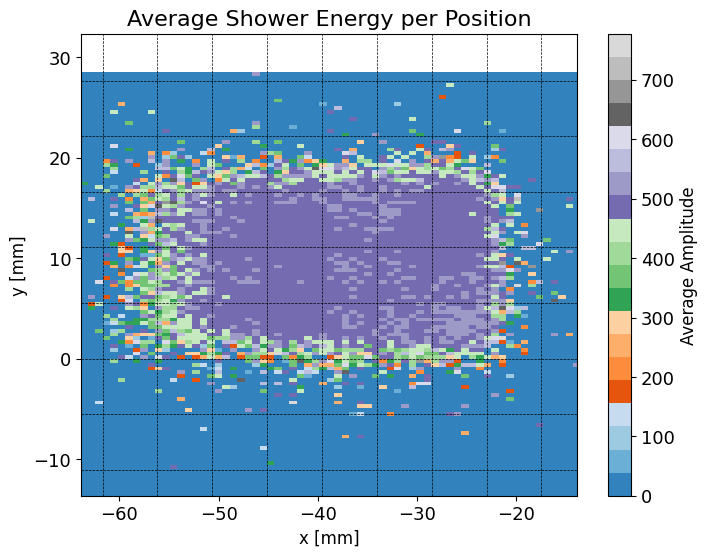

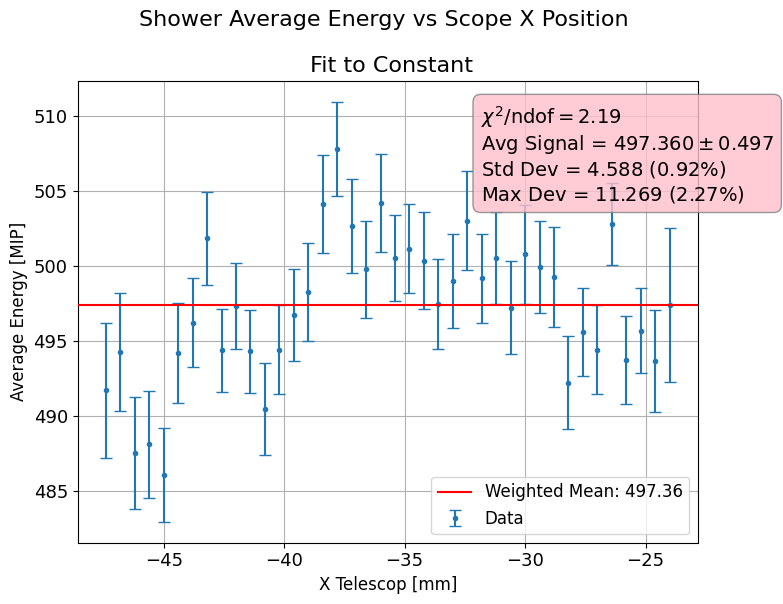

In [26]:
run_number = 1093

# Run Data
data_scope_corrected = ak.from_parquet(f"TB_FIRE/Pad_Corrected_Data/run_{run_number}_pad_corrected.parquet")

data_mip = convert_amp_to_MIP_asic_avg(data_scope_corrected, number_of_planes=8)

data_scope = data_mip

x_center, y_center = sf.avg_energy_scope_colormap(data_scope, x_shift=-3, y_borders=23 , amp_thresh=800)

# plot gap gaussian fit
y_range = 15
x_range = 15
y_min, y_max = y_center-y_range, y_center+y_range
x_min, x_max = x_center-x_range, x_center+x_range


E_vs_X_constant_fit(data_scope, 1.1, y_min, y_max, -48, x_max, bin_size=0.6)
# E_vs_X_constant_fit(data_scope, 1.1, 6, 11, -48, x_max, bin_size=0.6)